# Sentiment and Thematic Analysis

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath(".."))
from transformers import pipeline
from src.datapreprocessing import load_data

## Model Initialization

In [12]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2124.76it/s]


## Load Cleaned Dataset

In [13]:
df = load_data("../data/processed/cleaned_bank_reviews.csv")

## Predict Review Sentiment

In [14]:
sentiments = []
confidence_scores = []

for review in df["review"]:

    result = sentiment_pipeline(str(review))[0]

    label = result["label"]
    score = result["score"]

    if score < 0.60:
        sentiment = "Neutral"
    elif label == "POSITIVE":
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    sentiments.append(sentiment)
    confidence_scores.append(score)

df["sentiment"] = sentiments
df["confidence_score"] = confidence_scores

## Aggregating Sentiment Results

### Sentiment by Bank

In [16]:
bank_sentiment = df.groupby("bank")["confidence_score"].mean()

print(bank_sentiment)

bank
Bank of Abyssinia              0.962749
Commercial Bank of Ethiopia    0.980613
Dashen Bank                    0.970445
Name: confidence_score, dtype: float64


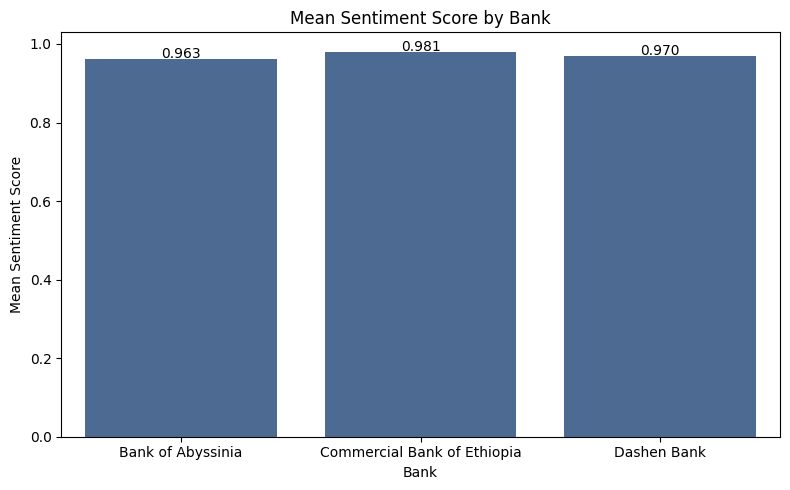

In [45]:
# Plot bar chart
plt.figure(figsize=(8, 5))

ax = bank_sentiment.plot(kind="bar")
bars = ax.bar(
    bank_sentiment.index,
    bank_sentiment.values,
    color="#4C6A92"
)
for i, value in enumerate(bank_sentiment):
    ax.text(
        i,                      # x position
        value + 0.001,          # y position
        f"{value:.3f}",         # text label
        ha='center'
    )
plt.title("Mean Sentiment Score by Bank")
plt.xlabel("Bank")
plt.ylabel("Mean Sentiment Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Sentiment by Star Rating

In [37]:
rating_sentiment = df.groupby("rating")["confidence_score"].mean()

print(rating_sentiment)

rating
1    0.981067
2    0.976401
3    0.971672
4    0.958388
5    0.969688
Name: confidence_score, dtype: float64


0 0.981067436447471
1 0.9764014448438372
2 0.971672106796587
3 0.958388386964798
4 0.9696881319940795


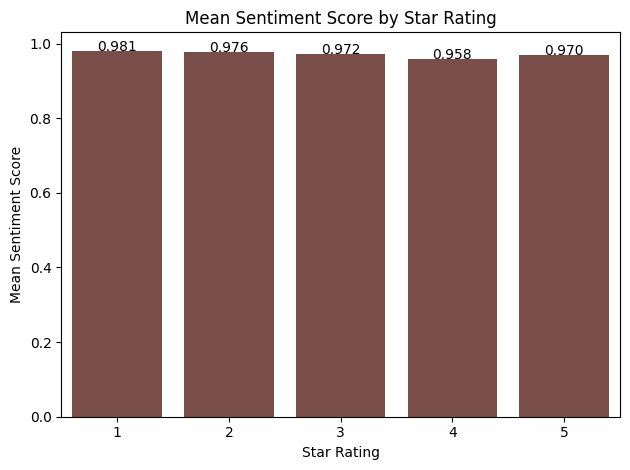

In [44]:
# Plot bars
ax = rating_sentiment.plot(kind="bar")
bars = ax.bar(
    rating_sentiment.index.astype(str),
    rating_sentiment.values,
    color="#7A4E48"
)
# Add values on top of bars
for i, value in enumerate(rating_sentiment):
    print(i,value)
    ax.text(
        i,
        value,
        f"{value:.3f}",
        ha='center'
    )

# Titles and labels
plt.title("Mean Sentiment Score by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Mean Sentiment Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()